# PLAN 08: geometry of the missing monodromy theorem

This notebook visualizes the theorem still missing behind PLAN 08.

Lean now has theorem surfaces for:

```lean
BasinLoop
LocalPullbackRootBranchData
AnalyticContinuationAlongBasinLoop
BasinLoopPullbackRootMonodromyData
```

but not their actual analytic construction.

The missing theorem says:

> local pullback root branches continue analytically along every basin loop, the result differs by a root-of-unity multiplier, and for the normalized Böttcher branch that multiplier is always $1$.

The visualization below separates the geometry into three layers:

1. a loop in the basin;
2. the image loop $A_N(z)=\Phi_\infty(f^N(z))$ in the punctured complex plane;
3. the continued $2^N$-root branch above that image loop.

In [1]:
import cmath
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

c = 2.0 + 0.0j

def f(z):
    return z*z + c

def iterate(z, n):
    for _ in range(n):
        z = f(z)
    return z

def phi_inf_approx(z, terms=50):
    s = 0.0 + 0.0j
    w = z
    for n in range(terms):
        s += (0.5 ** (n + 1)) * cmath.log(1 + c / (w*w))
        w = f(w)
        if abs(w) > 1e80:
            break
    return z * cmath.exp(s)

def continued_root(A_path, degree):
    phases = np.unwrap(np.angle(A_path)) / degree
    radii = np.abs(A_path) ** (1 / degree)
    return radii * np.exp(1j * phases)

def winding_number(path):
    return (np.unwrap(np.angle(path))[-1] - np.unwrap(np.angle(path))[0]) / (2*np.pi)


## A model basin loop and its $A_N$ image

For a genuine proof, the loop must live in the basin $U_\infty$. Here we use a controlled model loop to show the geometry of what Lean must formalize.

Given a loop $\gamma(t)$, define

$$
A_N(t)=\Phi_\infty(f^N(\gamma(t))).
$$

At level $N$, a local branch is a function $W_N(t)$ satisfying

$$
W_N(t)^{2^N}=A_N(t).
$$

The monodromy is the multiplier

$$
W_N(1)=\rho_N(\gamma)W_N(0),
\qquad \rho_N(\gamma)\in\mu_{2^N}.
$$

The missing theorem is $\rho_N(\gamma)=1$ for the normalized branch.

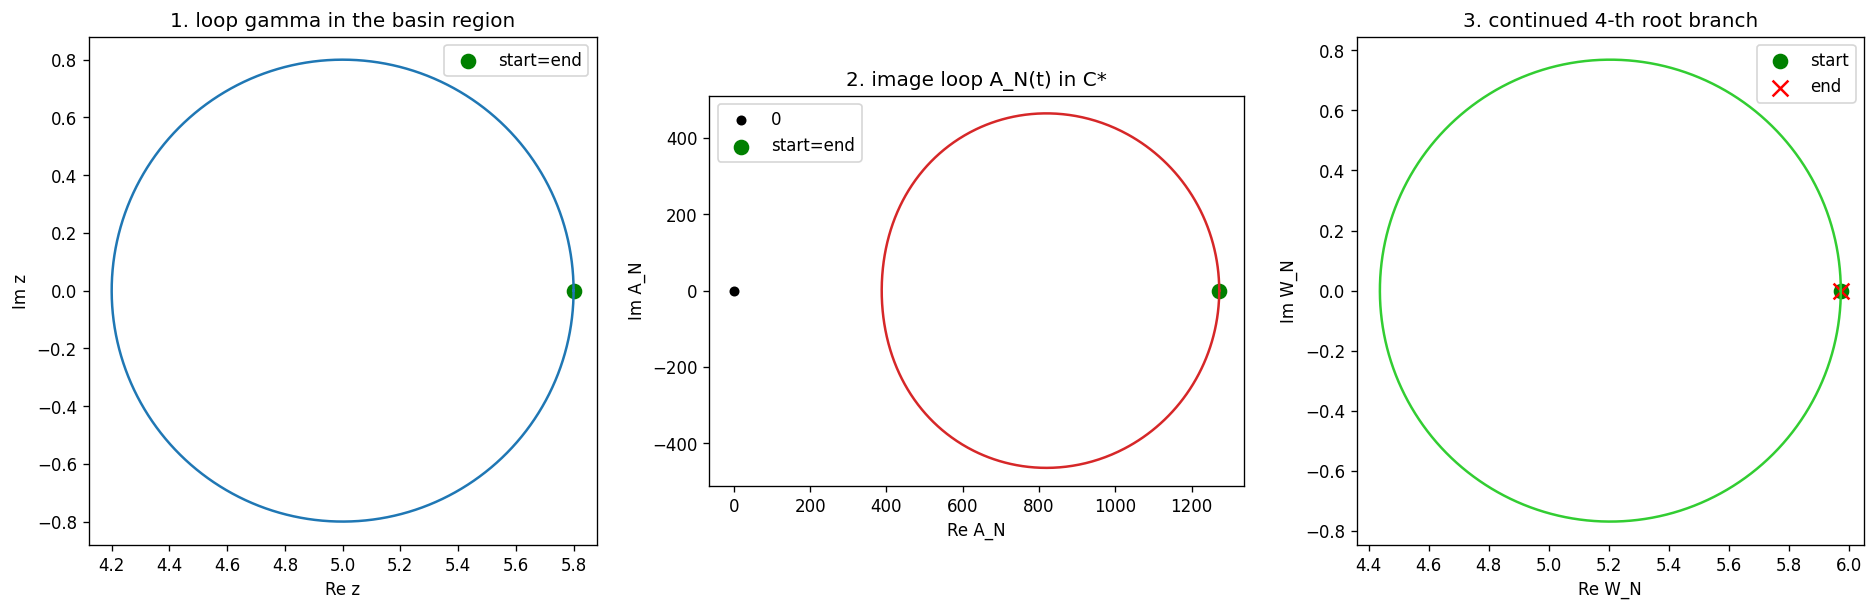

level N = 2, root degree = 4
winding number of A_N loop around 0 ≈ -2.02683e-17
monodromy multiplier rho = W_N(end)/W_N(start) ≈ 1-3.183738e-17j
is rho approximately 1? True


In [2]:
# Model loop in the z-plane. We choose a loop far enough out so the near-infinity
# approximation is meaningful and the picture is stable.
t = np.linspace(0, 2*np.pi, 800)
z_loop = 5.0 + 0.8 * np.exp(1j * t)
N = 2
A_loop = np.array([phi_inf_approx(iterate(z, N), terms=60) for z in z_loop])
degree = 2**N
root_loop = continued_root(A_loop, degree)

rho = root_loop[-1] / root_loop[0]
wind_A = winding_number(A_loop)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(z_loop.real, z_loop.imag, color='tab:blue')
ax.scatter([z_loop[0].real], [z_loop[0].imag], color='green', s=70, label='start=end')
ax.set_aspect('equal', adjustable='box')
ax.set_title('1. loop gamma in the basin region')
ax.set_xlabel('Re z')
ax.set_ylabel('Im z')
ax.legend()

ax = axes[1]
ax.plot(A_loop.real, A_loop.imag, color='tab:red')
ax.scatter([0], [0], color='black', s=25, label='0')
ax.scatter([A_loop[0].real], [A_loop[0].imag], color='green', s=70, label='start=end')
ax.set_aspect('equal', adjustable='box')
ax.set_title('2. image loop A_N(t) in C*')
ax.set_xlabel('Re A_N')
ax.set_ylabel('Im A_N')
ax.legend()

ax = axes[2]
ax.plot(root_loop.real, root_loop.imag, color='limegreen')
ax.scatter([root_loop[0].real], [root_loop[0].imag], color='green', s=70, label='start')
ax.scatter([root_loop[-1].real], [root_loop[-1].imag], color='red', marker='x', s=90, label='end')
ax.set_aspect('equal', adjustable='box')
ax.set_title(f'3. continued {degree}-th root branch')
ax.set_xlabel('Re W_N')
ax.set_ylabel('Im W_N')
ax.legend()

fig.tight_layout()
plt.show()

print(f'level N = {N}, root degree = {degree}')
print(f'winding number of A_N loop around 0 ≈ {wind_A:.6g}')
print(f'monodromy multiplier rho = W_N(end)/W_N(start) ≈ {rho:.8g}')
print(f'is rho approximately 1? {abs(rho - 1) < 1e-6}')

## What bad monodromy would look like

The previous loop is not meant as a counterexample; it is a geometric diagnostic. To see the obstruction clearly, compare with an artificial loop $A(t)$ that winds around $0$.

If $A(t)$ winds once and the root degree is $2^N$, the continued root returns multiplied by

$$
\exp(2\pi i/2^N).
$$

That is a nontrivial element of $\mu_{2^N}$, so the branch is not single-valued downstairs.

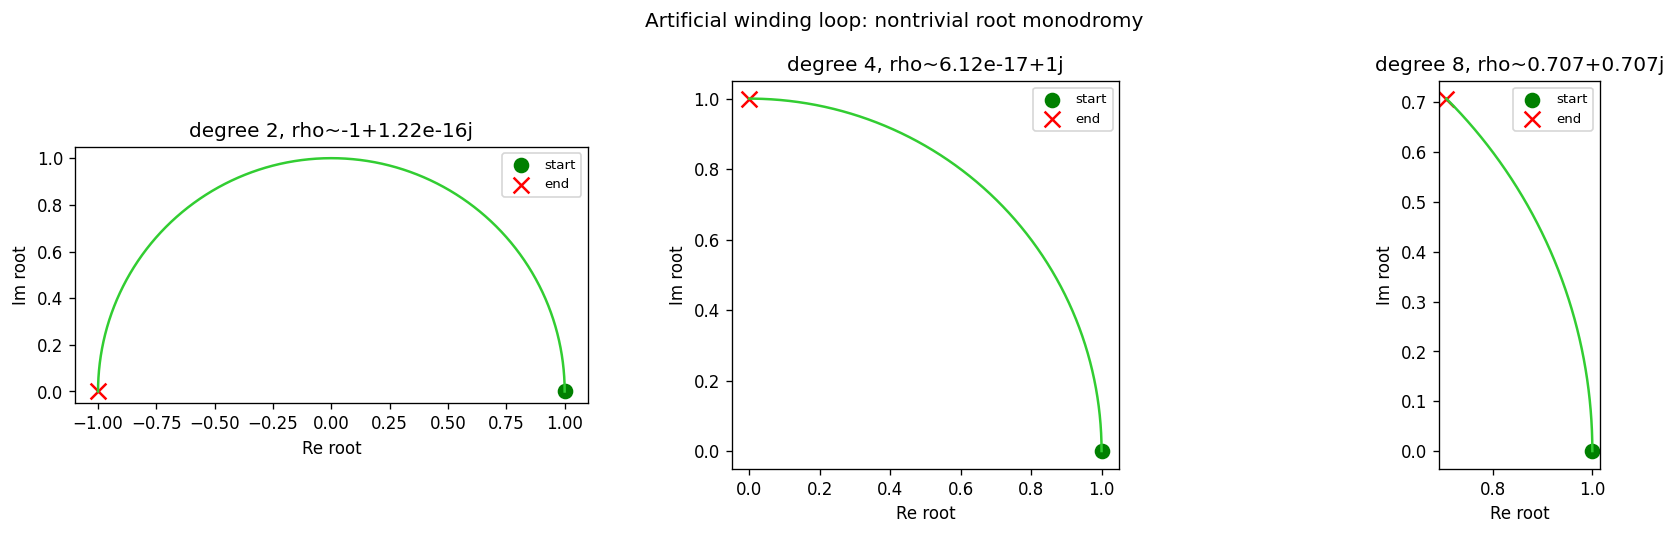

In [3]:
degrees = [2, 4, 8]
t = np.linspace(0, 2*np.pi, 800)
A_bad = np.exp(1j * t)

fig, axes = plt.subplots(1, len(degrees), figsize=(15, 4.5))
for ax, degree in zip(axes, degrees):
    root = continued_root(A_bad, degree)
    rho = root[-1] / root[0]
    ax.plot(root.real, root.imag, color='limegreen')
    ax.scatter([root[0].real], [root[0].imag], color='green', s=70, label='start')
    ax.scatter([root[-1].real], [root[-1].imag], color='red', marker='x', s=90, label='end')
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'degree {degree}, rho~{rho:.3g}')
    ax.set_xlabel('Re root')
    ax.set_ylabel('Im root')
    ax.legend(fontsize=8)
fig.suptitle('Artificial winding loop: nontrivial root monodromy')
fig.tight_layout()
plt.show()

## Special case proof: image loop lies in a simply connected disk avoiding zero

A clean special case of the missing theorem is the following.

Suppose the loop

$$
A_N(t)=\Phi_\infty(f^N(\gamma(t)))
$$

is contained in an open disk $D(a,r)$ such that

$$
0\notin D(a,r).
$$

Then $D(a,r)$ is simply connected and avoids zero, so there is a single holomorphic logarithm branch on that disk. Define

$$
W_N(t)=\exp\left(\frac{1}{2^N}\operatorname{Log}_D(A_N(t))\right).
$$

Because the same logarithm branch is used for the whole loop, $W_N(t)$ returns to its starting value. Hence the monodromy is trivial in this special case.

This is not the full basin theorem, because for a general basin loop the image $A_N(\gamma)$ may not be contained in one such disk. But it gives a rigorous local pattern:

1. find a simply connected zero-free neighborhood of the image;
2. choose a logarithm branch there;
3. define the root using that logarithm;
4. monodromy is automatically trivial.

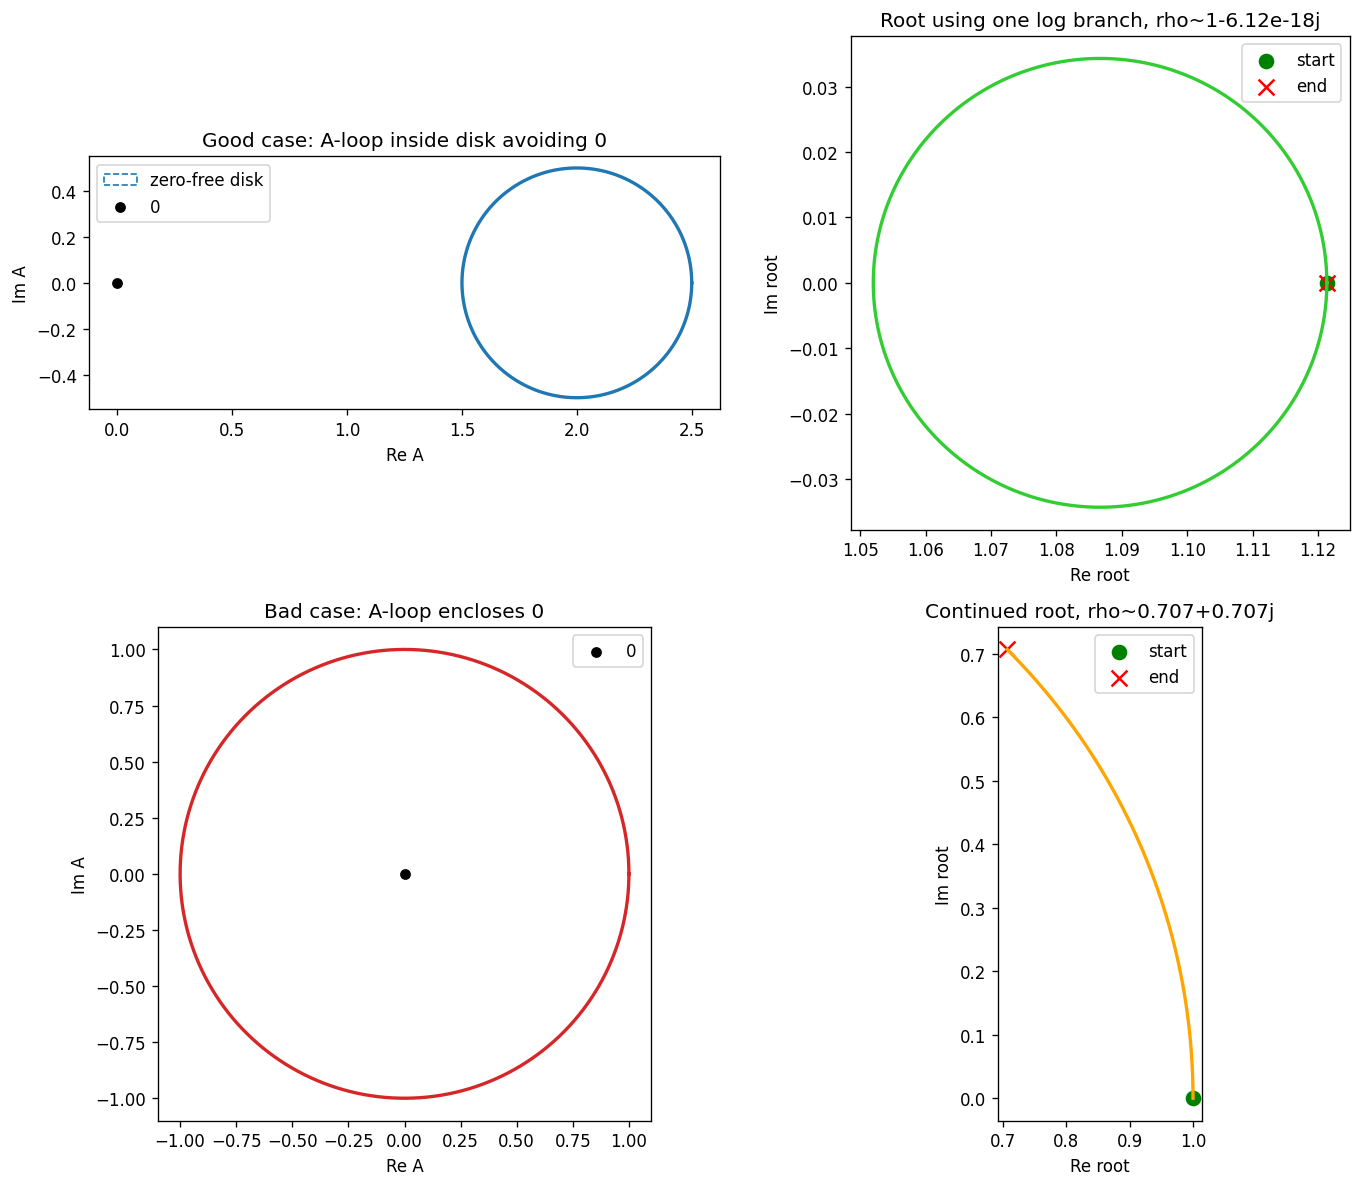

Good zero-free disk case:
  rho = (1-6.123233995736766e-18j) trivial= True
Bad winding case:
  rho = (0.7071067811865476+0.7071067811865475j) trivial= False


In [4]:
# Special case: a loop inside a disk centered at a=2, radius r=0.5.
# This disk avoids 0, so a single log branch exists.
a = 2.0 + 0.0j
r = 0.5
degree = 8
t = np.linspace(0, 2*np.pi, 600)
A_good = a + r * np.exp(1j * t)

# Use the logarithm branch Log_D induced by the principal log; since the disk
# stays in the right half-plane and avoids 0, this is continuous on the disk.
W_good = np.exp(np.log(A_good) / degree)
rho_good = W_good[-1] / W_good[0]

# Compare with a bad loop enclosing 0.
A_bad = np.exp(1j * t)
W_bad = continued_root(A_bad, degree)
rho_bad = W_bad[-1] / W_bad[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
ax.plot(A_good.real, A_good.imag, color='tab:blue', linewidth=2)
disk = plt.Circle((a.real, a.imag), r, fill=False, color='tab:blue', linestyle='--', label='zero-free disk')
ax.add_patch(disk)
ax.scatter([0], [0], color='black', s=30, label='0')
ax.set_aspect('equal', adjustable='box')
ax.set_title('Good case: A-loop inside disk avoiding 0')
ax.set_xlabel('Re A')
ax.set_ylabel('Im A')
ax.legend()

ax = axes[0, 1]
ax.plot(W_good.real, W_good.imag, color='limegreen', linewidth=2)
ax.scatter([W_good[0].real], [W_good[0].imag], color='green', s=70, label='start')
ax.scatter([W_good[-1].real], [W_good[-1].imag], color='red', marker='x', s=90, label='end')
ax.set_aspect('equal', adjustable='box')
ax.set_title(f'Root using one log branch, rho~{rho_good:.3g}')
ax.set_xlabel('Re root')
ax.set_ylabel('Im root')
ax.legend()

ax = axes[1, 0]
ax.plot(A_bad.real, A_bad.imag, color='tab:red', linewidth=2)
ax.scatter([0], [0], color='black', s=30, label='0')
ax.set_aspect('equal', adjustable='box')
ax.set_title('Bad case: A-loop encloses 0')
ax.set_xlabel('Re A')
ax.set_ylabel('Im A')
ax.legend()

ax = axes[1, 1]
ax.plot(W_bad.real, W_bad.imag, color='orange', linewidth=2)
ax.scatter([W_bad[0].real], [W_bad[0].imag], color='green', s=70, label='start')
ax.scatter([W_bad[-1].real], [W_bad[-1].imag], color='red', marker='x', s=90, label='end')
ax.set_aspect('equal', adjustable='box')
ax.set_title(f'Continued root, rho~{rho_bad:.3g}')
ax.set_xlabel('Re root')
ax.set_ylabel('Im root')
ax.legend()

fig.tight_layout()
plt.show()

print('Good zero-free disk case:')
print('  rho =', rho_good, 'trivial=', abs(rho_good - 1) < 1e-8)
print('Bad winding case:')
print('  rho =', rho_bad, 'trivial=', abs(rho_bad - 1) < 1e-8)

### How this special case would look in Lean

A possible local theorem surface is:

```lean
ZeroFreeDiskRootBranchData
```

with fields:

1. a disk `Metric.ball a r`;
2. proof `not (0 ∈ Metric.ball a r)`;
3. proof that `A_N` maps the chosen path or neighborhood into this disk;
4. a chosen logarithm branch on the disk;
5. root branch `fun z => exp ((logBranch (A_N z)) / 2^N)`;
6. proof that continuation around loops inside this disk has trivial monodromy.

This special case would not solve the full basin extension by itself, but it is a useful local building block. The full theorem would need to cover basin paths by overlapping zero-free disks and prove the local branches agree on overlaps.

## What Lean must prove

For the actual basin and the actual function

$$
A_N(z)=\Phi_\infty(f^N(z)),
$$

Lean must prove the following theorem, not merely inspect numerical loops:

1. every local root branch can be analytically continued along every `BasinLoop`;
2. the endpoint branch differs from the starting branch by a unique element of $\mu_{2^N}$;
3. these elements are compatible as $N$ changes;
4. for the normalized branch, all monodromy elements are $1$.

The theorem surfaces now in Lean are:

```lean
BasinLoop
LocalPullbackRootBranchData
AnalyticContinuationAlongBasinLoop
BasinLoopPullbackRootMonodromyData
PullbackRootMonodromyRepresentation.Trivial
```

The missing construction is an actual proof of these fields for the basin of $z^2+2$.